Размер исходного датасета: (5000, 8)

Первые пять строк:
  Transaction_ID Transaction_Date Customer_ID    Product_Name  Quantity  \
0          T0001       2024-08-02       C2205      Headphones      -5.0   
1          T0002       2020-02-10       C3156         Coffee      469.0   
2          T0003       2025-02-30       C2919          Tablet      -4.0   
3          T0004       2020-08-17       C3009             Tab      -7.0   
4          T0005       2025-02-30       C3488  Coffee Machine     -10.0   

                 Price Payment_Method Transaction_Status  
0              $420.21        pay pal                NaN  
1  -445.34202525395585     creditcard            Pending  
2    810.9930123946459    credit card          completed  
3    868.6083413217348         PayPal            Pending  
4   -763.1224490039416         PayPal          completed  

Отчет о пропусках до обработки:
                    missing_count  missing_percent
Transaction_ID                252             5.04
Tra

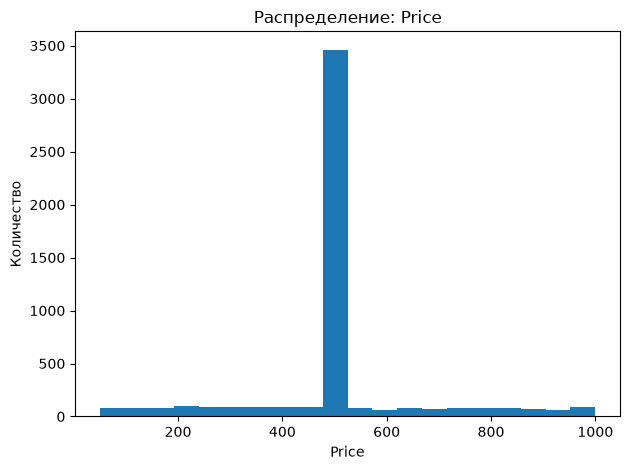

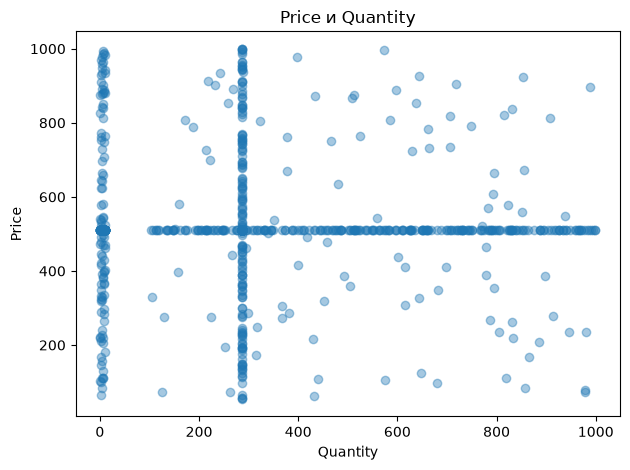

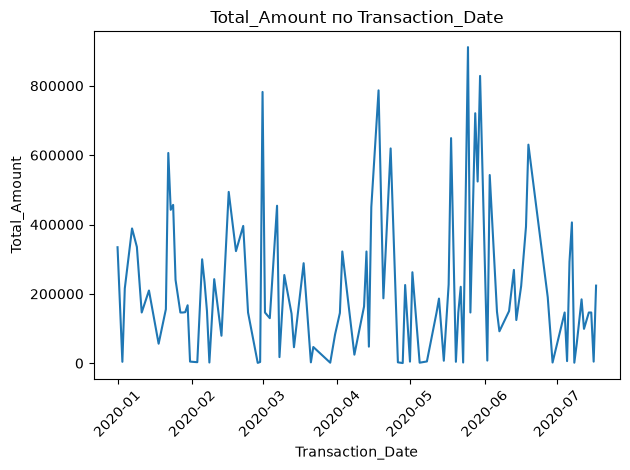


Результаты модели:
{'MSE': 26527.04, 'R2': -0.002}

Обработанный датасет сохранен.


In [2]:
from data_loader import DataLoader
from data_processing import DataProcessor
from missing_values import MissingValuesHandler
from visualization import DataVisualizer
from model import TransactionPriceModel


# 1. Загружаем исходный датасет.
data = DataLoader.load_csv("dirty_financial_transactions.csv")

print("Размер исходного датасета:", data.shape)
print("\nПервые пять строк:")
print(data.head())


# 2. Создаем отчет о пропусках до обработки.
print("\nОтчет о пропусках до обработки:")
print(MissingValuesHandler.missing_report(data))


# 3. Очищаем и преобразуем данные.
clean_data = DataProcessor.prepare_data(data)

print("\nКоличество строк после удаления дубликатов:", len(clean_data))


# 4. Заполняем пропуски там, где это обоснованно.
clean_data = MissingValuesHandler.fill_numeric(
    clean_data,
    "Quantity",
    method="mean"
)

clean_data = MissingValuesHandler.fill_numeric(
    clean_data,
    "Price",
    method="mean"
)

clean_data = MissingValuesHandler.fill_categorical(
    clean_data,
    "Transaction_Status"
)

print("\nОтчет о пропусках после частичного заполнения:")
print(MissingValuesHandler.missing_report(clean_data))


# 5. Создаем новый расчетный столбец.
clean_data["Total_Amount"] = (
    clean_data["Quantity"] * clean_data["Price"]
)

# 6. Строим визуализации.
visualizer = DataVisualizer()

visualizer.add_histogram(
    clean_data,
    "Price"
)

visualizer.add_scatter_plot(
    clean_data.sample(1000, random_state=42),
    "Quantity",
    "Price"
)

daily_sales = (
    clean_data
    .dropna(subset=["Transaction_Date"])
    .groupby("Transaction_Date", as_index=False)["Total_Amount"]
    .sum()
    .sort_values("Transaction_Date")
)

visualizer.add_line_plot(
    daily_sales.head(100),
    "Transaction_Date",
    "Total_Amount"
)

visualizer.remove_visualization()


# 7. Обучаем простую модель линейной регрессии.
price_model = TransactionPriceModel()

X_train, X_test, y_train, y_test = (
    price_model.prepare_model_data(clean_data)
)

price_model.train(X_train, y_train)
predictions = price_model.predict(X_test)
metrics = price_model.evaluate(y_test, predictions)

print("\nРезультаты модели:")
print(metrics)


# 8. Сохраняем обработанные данные.
clean_data.to_csv(
    "clean_financial_transactions.csv",
    index=False
)

print("\nОбработанный датасет сохранен.")
